### So here we are analysing a "bike sharing dataset" and columns of the dataset provide the following information:
datetime - hourly date + timestamp<br>
season -  1 = spring, 2 = summer, 3 = fall, 4 = winter<br> 
holiday - whether the day is considered a holiday<br>
workingday - whether the day is neither a weekend nor holiday<br>
weather - 1: Clear, Few clouds, Partly cloudy, Partly cloudy<br>
          2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist<br>
          3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds<br>
          4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog <br>
temp - temperature in Celsius<br>
atemp - "feels like" temperature in Celsius<br>
humidity - relative humidity<br>
windspeed - wind speed<br>
casual - number of non-registered user rentals initiated<br>
registered - number of registered user rentals initiated<br>
count - number of total rentals<br>


<p><strong>So at first we import the required modules for the assignment</strong></p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.decomposition import PCA

<h2>Phase 1 part 1</h2>
<p>In the next 3 code cells I looked at the information about our data like its shape, size, columns name and then converted the datetime column from <strong>object datatype to datetime datatype</strong></p>

In [2]:
df = pd.read_csv("/kaggle/input/datasets/tanishab1192/bikesharingdataset/train.csv")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


(10886, 12)

In [4]:
df['datetime'] = pd.to_datetime(df['datetime'])

df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.dayofweek

df = df.drop(columns=['datetime'])
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,month,day_of_week
0,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,1,5
1,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,5
2,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,1,5
3,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,1,5
4,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,1,5


<h2>Phase 1 part 2</h2>
<p>In the next couple of code cells I have plotted the graph between average bike rentals vs hour and season </p>

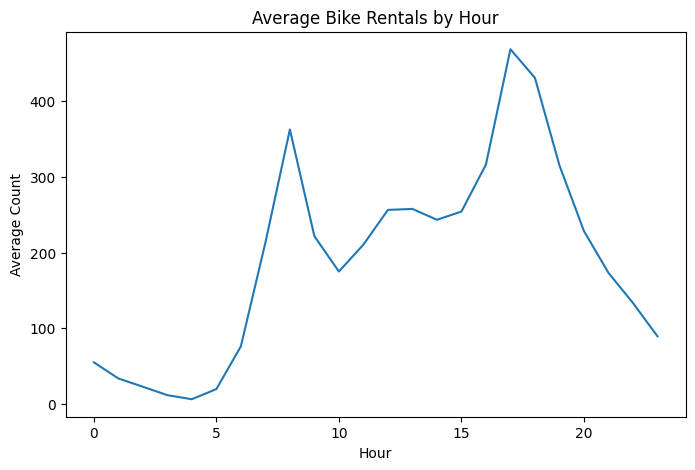

In [5]:
hourly_avg = df.groupby('hour')['count'].mean()

plt.figure(figsize=(8,5))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values)
plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Count")
plt.show()

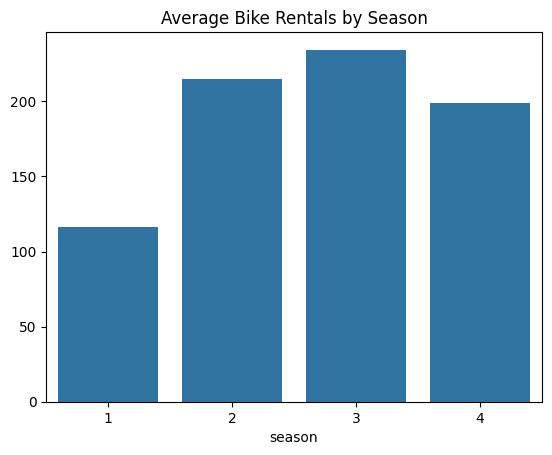

In [6]:
season_avg = df.groupby('season')['count'].mean()

sns.barplot(x=season_avg.index, y=season_avg.values)
plt.title("Average Bike Rentals by Season")
plt.show()

<p>We can clearly observe that bikes are mostly rented around hours 7-8 and 16-18 and it stabilizes during day time at around 12 and is quite low between 0-5 and descends rapidly after 20 which indicates that <strong>hour is a really imp feature for predicting bike demand.</strong>
In the season bar plot it can clearly be observed that the demand is highest in fall/autumn and lowest in spring <strong>so our data varies with the season as well showing it is an important aspect for predicting bike demand</strong></p>

<h2>Phase 1 part 3</h2>
<p>Here I have plotted the heat map betweeen weather variables i.e., <strong>temp, atemp, humidity, and windspeed.</strong> </p>

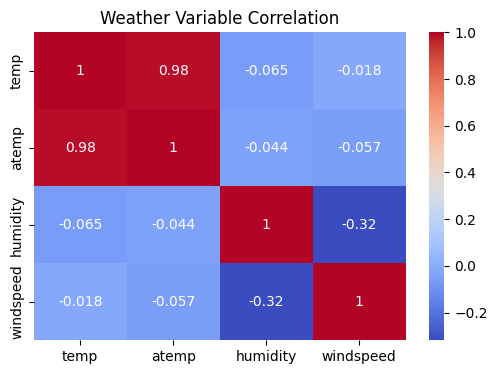

In [7]:
weather_vars = ['temp','atemp','humidity','windspeed']

plt.figure(figsize=(6,4))
sns.heatmap(df[weather_vars].corr(), annot=True, cmap="coolwarm")
plt.title("Weather Variable Correlation")
plt.show()

<p>The correlation heatmap of weather-related variables reveals a <strong>very strong positive correlation (≈ 0.98) between temperature (temp) and perceived temperature (atemp)</strong>, indicating significant redundancy between these features. This suggests the presence of multicollinearity, which can negatively impact linear models.

Other variables such as <strong>humidity and windspeed show relatively weak correlations with temperature</strong>, indicating that they contribute independent information. A moderate negative correlation is observed between humidity and windspeed, suggesting a slight inverse relationship.</p>

<h2>Phase 1 part 4</h2>
<p>Now we have to apply PCA for dimensionality reduction. In the next 3 code cells I have applied PCA without standardization and with standarardization to show the effect of standardization on PCA</p>

In [8]:
weather_features = ['temp','atemp','humidity','windspeed']
X_weather = df[weather_features]

pca_raw = PCA()

pca_raw.fit(X_weather)

print("Explained Variance Ratio (without scaling):")
print(pca_raw.explained_variance_ratio_)

Explained Variance Ratio (without scaling):
[0.66529623 0.23080937 0.1022523  0.00164211]


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_weather)

pca_scaled = PCA()
pca_scaled.fit(X_scaled)

print("Explained Variance Ratio (with scaling):")
print(pca_scaled.explained_variance_ratio_)

Explained Variance Ratio (with scaling):
[0.49795053 0.32972953 0.1687666  0.00355333]


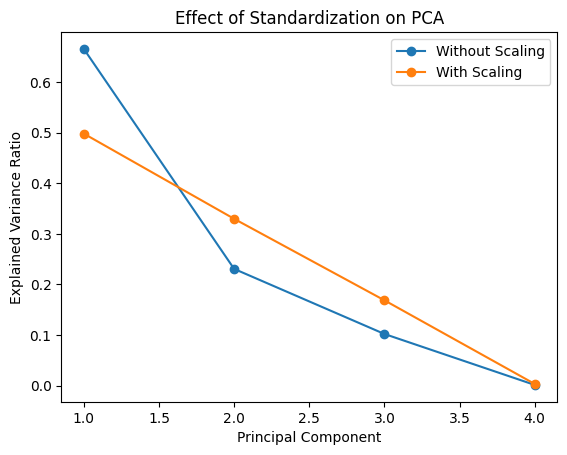

In [10]:
components = np.arange(1,5)

plt.plot(components, pca_raw.explained_variance_ratio_, marker='o', label="Without Scaling")
plt.plot(components, pca_scaled.explained_variance_ratio_, marker='o', label="With Scaling")

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Effect of Standardization on PCA")
plt.legend()
plt.show()

<p>Without scaling, the first principal component explained approximately 66% of the variance, indicating that variables with larger numerical ranges dominated the PCA transformation. After applying standardization, the variance distribution became more balanced across the first three principal components. This shows that scaling allowed PCA to capture the true relationships between weather variables rather than being influenced by feature magnitude. Therefore, PCA was applied after standardization in the final preprocessing pipeline of phase 2.</p>

<h2>Phase 2</h2>
<p>Now we will build a scikit-learn column transformer pipeline to apply standard scaler to pca features and one-hot encoding to categorical features and then apply linear regression and decision tree regressor and compare their accuracies</p>

<P>In the following code cells I have applied train test split and created the scikit learn column transformer</p>

In [11]:
X = df.drop(columns=['count', 'casual', 'registered'])
y = df['count']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
weather_features = ['temp', 'atemp', 'humidity', 'windspeed']
numerical_features = ['hour', 'month']
categorical_features = ['season', 'weather', 'day_of_week']

In [12]:
weather_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('weather_pca', weather_pipeline, weather_features),
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

<p>Now we will aply linear regression and find its R2 score and RMSE value</p>

In [13]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('weather_pca',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=2))]),
                                                  ['temp', 'atemp', 'humidity',
                                                   'windspeed']),
                                                 ('num', StandardScaler(),
                                                  ['hour', 'month']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['season', 'weather',
                                                   'day_of_week'])])),
                ('model', LinearRegression())])

In [14]:
lr_pred = lr_pipeline.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression R2:", lr_r2)
print("Linear Regression RMSE:", lr_rmse)

Linear Regression R2: 0.34219862794770983
Linear Regression RMSE: 147.34994977692728


<p>Now we will apply Decision tree regressor amd find its R2 score and RMSE value</p>

In [15]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=10, random_state=42))
])

dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('weather_pca',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=2))]),
                                                  ['temp', 'atemp', 'humidity',
                                                   'windspeed']),
                                                 ('num', StandardScaler(),
                                                  ['hour', 'month']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['season', 'weather',
                                                   'day_of_week'])])),
                ('model',
                 DecisionTreeRegressor(max_depth=10, random_state=42))])

In [16]:
dt_pred = dt_pipeline.predict(X_test)

dt_r2 = r2_score(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

print("Decision Tree R2:", dt_r2)
print("Decision Tree RMSE:", dt_rmse)

Decision Tree R2: 0.7661196042363799
Decision Tree RMSE: 87.86168233683654


<p>Here we will tune the depth hyper parameter by trying many different values for it so that the value of RMSE is minimum</p>

In [17]:
for depth in [3,5,7,8,9,10,11,12]:
    
    dt = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(max_depth=depth, random_state=42))
    ])
    
    dt.fit(X_train, y_train)
    
    pred = dt.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    
    print(f"Depth {depth} → RMSE: {rmse}")

Depth 3 → RMSE: 131.38559166435763
Depth 5 → RMSE: 114.47957916050127
Depth 7 → RMSE: 97.72370196488129
Depth 8 → RMSE: 93.27472281246567
Depth 9 → RMSE: 88.56377381336961
Depth 10 → RMSE: 87.86168233683654
Depth 11 → RMSE: 90.81725264950235
Depth 12 → RMSE: 92.53030403037586


<p>Clearly the value of RMSE was minimum for depth=10 thats why i set the value of depth as 10 in the original decision tree regressor code</p>

<p>Now we wil compare the RMSE values of both the models</p>

In [18]:
print("Model Comparison")

print("Linear Regression RMSE:", lr_rmse)
print("Decision Tree RMSE:", dt_rmse)

Model Comparison
Linear Regression RMSE: 147.34994977692728
Decision Tree RMSE: 87.86168233683654


<p>Clearly the RMSE value is much less for the decision tree regressor as compared to linear regression this is because Linear Regression provides a simple baseline model but assumes linear relationships between features and bike demand. <strong>The Decision Tree Regressor captures nonlinear interactions between weather and temporal features.</strong> As a result, the Decision Tree achieved lower RMSE on the test set, indicating better predictive performance.</p>

<h2>Phase 3</h2>
<p>In the next 3 code cells I have at first calculated the median of the count column and created a binary target column high_demand with values 1 if count > median, else 0.</p>
<p>Then I have applied logistic regression with the same pipeline used in phase 2 and calculated its acuracy precison and recall</p>

In [19]:
median_count = df['count'].median()

df['high_demand'] = (df['count'] > median_count).astype(int)

df[['count','high_demand']].head()

,count,high_demand
0,16,0
1,40,0
2,32,0
3,13,0
4,1,0


In [20]:
X = df.drop(columns=['count','casual','registered','high_demand'])
y = df['high_demand']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_pipeline.fit(X_train, y_train)
log_pred = log_pipeline.predict(X_test)

In [21]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)

print("Logistic Regression Results")
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)

Logistic Regression Results
Accuracy: 0.7777777777777778
Precision: 0.7811038353601497
Recall: 0.7695852534562212


<p>Now I made a decision tree classifier in the next 2 code cells and calculated its accuracy, precision and recall values as well</p>

In [22]:
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=8, random_state=42))
])

tree_pipeline.fit(X_train, y_train)
tree_pred = tree_pipeline.predict(X_test)

In [23]:
tree_accuracy = accuracy_score(y_test, tree_pred)
tree_precision = precision_score(y_test, tree_pred)
tree_recall = recall_score(y_test, tree_pred)

print("Decision Tree Results")
print("Accuracy:", tree_accuracy)
print("Precision:", tree_precision)
print("Recall:", tree_recall)

Decision Tree Results
Accuracy: 0.8613406795224977
Precision: 0.8331914893617022
Recall: 0.9023041474654377


<p>Now we will compare the accuracies of both the models</p>

In [24]:
print("Model Comparison")

print("Logistic Regression Accuracy:", log_accuracy)
print("Decision Tree Accuracy:", tree_accuracy)

Model Comparison
Logistic Regression Accuracy: 0.7777777777777778
Decision Tree Accuracy: 0.8613406795224977


<p>Clearly the accuracy of Decision tree classifier is more than logistic regression because it was able to capture the complex non linear relation of data while logistic regression being a linear model is limited to finding a single linear boundary to separate classesso couldn't capture those non linearities</p>

<p>Now I have Extracted and plotted the feature importances from the Decision Tree to identify the most critical variables</p>

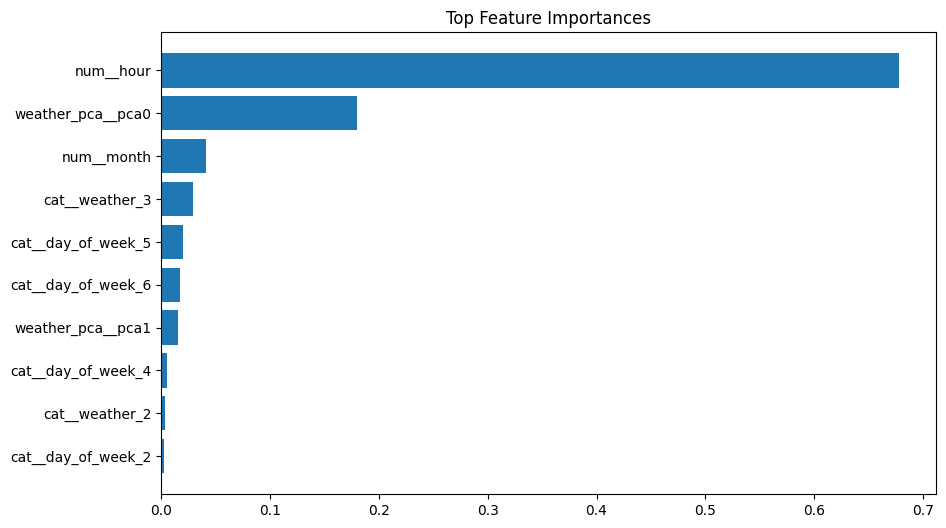

In [25]:
tree_model = tree_pipeline.named_steps['model']
importances = tree_model.feature_importances_
feature_names = tree_pipeline.named_steps['preprocessor'].get_feature_names_out()
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

importance_df = importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'][:10], importance_df['importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.show()

<p>The feature importance analysis reveals that the hour of the day is by far the most significant predictor of bike demand. The first principal component of the weather variables is the second most important feature, indicating that combined weather conditions such as temperature and humidity play a substantial role in influencing demand. Other features such as month and categorical variables like day of the week and weather conditions have relatively lower importance.</p>